# FLASHKNiFE measured-versus-simulated PDD figure maker

This notebook compares unchanged measured PDD data with Geant4 PDD curves. Only
the **simulation** can be adjusted toward measurement in explicitly configured
depth regions. Original and displayed simulated values are exported for audit.

The difference is **Geant4 − measured**. Gamma uses measured data as reference.
Simulation matching is a post-hoc sensitivity/visualization operation and must
not be described as independent validation.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.grid": False,
    "axes.linewidth": 0.9,
    "savefig.facecolor": "white",
})

## 1. Settings — edit this cell

In [9]:
# ------------------------- FILES -------------------------
DATA_FILE = Path("FLASHKNiFE_PDD_input_data.csv")
OUTPUT_DIR = Path("pdd_figure_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PNG_NAME = "FLASHKNiFE_PDD_comparison_300dpi.png"
SVG_NAME = "FLASHKNiFE_PDD_comparison.svg"
SUMMARY_NAME = "FLASHKNiFE_PDD_comparison_summary.csv"
JOURNAL_TABLE_NAME = "FLASHKNiFE_PDD_journal_table.csv"
POINTWISE_NAME = "FLASHKNiFE_PDD_pointwise_comparison.csv"
GAMMA_POINTWISE_NAME = "FLASHKNiFE_PDD_gamma_with_uncertainty.csv"

# ------------- SIMULATION-ONLY REGIONAL MATCHING -----------
# Measured depth and dose values are NEVER changed. Each simulation tuple is:
# (start_depth_mm, end_depth_mm, match_strength, blend_mm)
# adjusted_sim = original_sim + strength * (measured - original_sim)
# 0.90 closes 90% of the gap; 1.00 puts simulation on interpolated measurement.
ENABLE_SIMULATION_ADJUSTMENT = True
# Independent tuning control for each energy/applicator PDD. A scale of 0.0
# leaves that simulation unchanged; 1.0 applies its full per-region strengths.
# Intermediate values apply that fraction of the configured adjustment.
SIMULATION_MATCH_SCALES = {
    (9, 10): 0.80,
    (9, 5):  0.80,
    (9, 2):  0.90,
    (6, 10): 0.70,
    (6, 5):  0.70,
    (6, 2):  0.80,
}

SIMULATION_MATCH_RANGES = {
    # ---------------------------------------------------------
    # 9 MeV / 10 cm — five regions across 0–70 mm
    # ---------------------------------------------------------
    (9, 10): [
        (0.0,  12.0, 0.60, 1.5),
        (12.0, 25.0, 0.70, 2.0),
        (25.0, 40.0, 0.90, 2.0),
        (40.0, 55.0, 0.70, 2.0),
        (55.0, 70.0, 0.70, 1.5),
    ],

    # ---------------------------------------------------------
    # 9 MeV / 5 cm — five regions across 0–70 mm
    # ---------------------------------------------------------
    (9, 5): [
        (0.0,  12.0, 0.80, 1.5),
        (12.0, 25.0, 0.80, 2.0),
        (25.0, 40.0, 0.80, 2.0),
        (40.0, 55.0, 0.80, 2.0),
        (55.0, 70.0, 0.70, 1.5),
    ],

    # ---------------------------------------------------------
    # 9 MeV / 2 cm — earlier falloff, five regions
    # ---------------------------------------------------------
    (9, 2): [
        (0.0,   8.0, 0.80, 1.5),
        (8.0,  18.0, 0.80, 1.5),
        (18.0, 32.0, 0.90, 2.0),
        (32.0, 48.0, 0.80, 2.0),
        (48.0, 70.0, 0.85, 1.5),
    ],

    # ---------------------------------------------------------
    # 6 MeV / 10 cm — five regions across 0–50 mm
    # ---------------------------------------------------------
    (6, 10): [
        (0.0,   8.0, 0.70, 1.5),
        (8.0,  18.0, 0.70, 1.5),
        (18.0, 28.0, 0.85, 2.0),
        (28.0, 40.0, 0.50, 2.0),
        (40.0, 50.0, 0.25, 1.5),
    ],

    # ---------------------------------------------------------
    # 6 MeV / 5 cm — five regions across 0–50 mm
    # ---------------------------------------------------------
    (6, 5): [
        (0.0,   8.0, 0.40, 1.5),
        (8.0,  18.0, 0.70, 1.5),
        (18.0, 28.0, 0.85, 2.0),
        (28.0, 40.0, 0.50, 2.0),
        (40.0, 50.0, 0.25, 1.5),
    ],

    # ---------------------------------------------------------
    # 6 MeV / 2 cm — stronger early, central, and tail matching
    # ---------------------------------------------------------
    (6, 2): [
        (0.0,   8.0, 0.85, 1.5),
        (8.0,  18.0, 0.85, 1.5),
        (18.0, 28.0, 0.90, 2.0),
        (28.0, 40.0, 0.90, 2.0),
        (40.0, 50.0, 0.90, 1.5),
    ],
}

SHOW_UNCERTAINTY_BANDS = False
CLIP_ADJUSTED_SIMULATION_TO_ZERO = False




In [10]:
# --------------------- UNCERTAINTY ------------------------
# Measured charge readings were repeated three times and were identical within
# recorded precision; keep repeatability as 0 unless new repeat data are loaded.
MEASURED_REPEAT_COUNT = 3
MEASURED_REPEATABILITY_UNCERTAINTY_PCT = 0.0
MEASURED_DEPTH_STEP_MM = 1.0
# Treat the unresolved position within one sampling interval as rectangular.
MEASURED_DEPTH_POSITION_LIMIT_MM = MEASURED_DEPTH_STEP_MM / 2.0
MEASURED_DEPTH_POSITION_STANDARD_UNCERTAINTY_MM = MEASURED_DEPTH_STEP_MM / np.sqrt(12.0)
UNCERTAINTY_COVERAGE_FACTOR = 2.0


# Geant4 Monte Carlo relative statistical uncertainty summary (%). These values
# are reported in the manuscript table and summary CSV; they are not used to
# re-weight, smooth, or modify either PDD curve.
MC_UNCERTAINTY_SUMMARY = {
    (9, 10): {"u_mc_at_dmax_pct": 0.337, "u_mc_mean_above_10pct_pct": 0.473, "u_mc_max_above_10pct_pct": 1.246},
    (9, 5):  {"u_mc_at_dmax_pct": 0.276, "u_mc_mean_above_10pct_pct": 0.389, "u_mc_max_above_10pct_pct": 0.993},
    (9, 2):  {"u_mc_at_dmax_pct": 0.241, "u_mc_mean_above_10pct_pct": 0.362, "u_mc_max_above_10pct_pct": 0.880},
    (6, 10): {"u_mc_at_dmax_pct": 0.458, "u_mc_mean_above_10pct_pct": 0.649, "u_mc_max_above_10pct_pct": 1.620},
    (6, 5):  {"u_mc_at_dmax_pct": 0.376, "u_mc_mean_above_10pct_pct": 0.522, "u_mc_max_above_10pct_pct": 1.282},
    (6, 2):  {"u_mc_at_dmax_pct": 0.367, "u_mc_mean_above_10pct_pct": 0.541, "u_mc_max_above_10pct_pct": 1.354},
}

# -------- STANDARDIZED COMMON-GRID EVALUATION ------------
COMMON_DEPTH_GRID_MM = np.arange(1.0, 61.0, 1.0)
COMMON_GRID_INTERPOLATION = "linear (numpy.interp)"
COMMON_GRID_TABLE_NAME = "FLASHKNiFE_PDD_common_grid_gamma_table.csv"

# ----------------------- GAMMA ----------------------------
GAMMA_DOSE_CRITERION_PCT = 2.0
GAMMA_DISTANCE_CRITERION_MM = 2.0
# Journal reporting definition: measured reference, adjusted simulation evaluated,
# global normalization to the common 100% PDD scale, and a 10% reference threshold.
GAMMA_THRESHOLD_PCT = 10.0
GAMMA_SEARCH_STEP_MM = 0.025
GAMMA_METHOD_LABEL = "1D global gamma, 2%/2 mm, 10% measured-reference threshold, 1-60 mm common grid"

# ------------------- DIFFERENCE PANEL ---------------------
DIFFERENCE_MODE = "percentage_points"
DIFFERENCE_BAND = 5.0
DIFFERENCE_YLIM = (-5.0, 5.0)
# Focus the diagnostic view on the passing range. Values above 1 remain in CSVs
# and are marked by triangles at the upper plot boundary rather than hidden silently.
GAMMA_PLOT_YMAX = 1.0

# ----------------------- AXES -----------------------------
DEPTH_XLIM_MM = {9: (1.0, 60.0), 6: (1.0, 60.0)}
PDD_YLIM = (0.0, 105.0)
MAJOR_X_TICK_MM = 10.0
MINOR_X_TICK_MM = 5.0

# ----------------------- STYLE ----------------------------
MEASURED_LINEWIDTH = 3.0
MEASURED_LINESTYLE = "--"
SIMULATION_LINEWIDTH = 3.2
DIFFERENCE_LINEWIDTH = 2.8
GAMMA_LINEWIDTH = 2.8
AXIS_LINEWIDTH = 1.7
RAW_POINT_MARKER_SIZE = 2.2
# Uncertainty remains calculated/exported even when its shaded plot bands are hidden.
SHOW_UNCERTAINTY_BANDS = False

# -------- OPTIONAL SYNTHETIC DEMONSTRATION ONLY --------
# This never changes the manuscript figure, gamma pass rates, tables, or scientific
# CSVs. When enabled it creates clearly and separately named demo outputs.
GENERATE_SYNTHETIC_DEMO = False
SYNTHETIC_DEMO_RANDOM_SEED = 20260806
SYNTHETIC_DEMO_NOISE = {
    # (dose-difference standard deviation in pp, gamma standard deviation)
    (9, 10): (0.20, 0.035),
    (9, 5):  (0.20, 0.035),
    (9, 2):  (0.25, 0.040),
    (6, 10): (0.20, 0.035),
    (6, 5):  (0.20, 0.035),
    (6, 2):  (0.25, 0.040),
}
# Sparse heavy-tailed impulses make the separate demo visibly spiky.
# Each tuple is (point probability, dose spike scale in pp, gamma spike scale).
SYNTHETIC_DEMO_SPIKES = {
    (9, 10): (10, 10.30, 4.25),
    (9, 5):  (10.80, 10.30, 4.25),
    (9, 2):  (10.85, 10.50, 4.30),
    (6, 10): (10.80, 5.30, 4.25),
    (6, 5):  (10.80, 5.30, 4.25),
    (6, 2):  (10.85, 5.50, 4.30),
}
# PNG export resolution (dots per inch).
DPI = 300
FIGURE_SIZE_INCHES = (15.5, 11.5)




# ---------------- JOURNAL-STYLE TYPOGRAPHY ---------------
TITLE_FONTSIZE = 20
PANEL_TITLE_FONTSIZE = 12
AXIS_LABEL_FONTSIZE = 11
TICK_LABEL_FONTSIZE = 9
LEGEND_FONTSIZE = 9
ANNOTATION_FONTSIZE = 9
COLOURS = {
    "measured": "#0072B2",
    "simulated": "#D55E00",
    "difference": "#009E73",
    "gamma": "#CC79A7",
    "reference": "#7A7A7A",
}

## 2. Load and check the measured and simulated data

In [11]:
data = pd.read_csv(DATA_FILE)

required_columns = {
    "energy_MeV", "applicator_cm", "run_id", "source", "depth_mm", "norm_pct"
}
missing = required_columns.difference(data.columns)
if missing:
    raise ValueError(f"Missing columns in {DATA_FILE}: {sorted(missing)}")

data["source"] = data["source"].replace({"Geant4": "simulated"})
expected_cases = [(9, 10), (9, 5), (9, 2), (6, 10), (6, 5), (6, 2)]

for energy, applicator in expected_cases:
    case = data.query("energy_MeV == @energy and applicator_cm == @applicator")
    sources = set(case["source"])
    if sources != {"measured", "simulated"}:
        raise ValueError(
            f"{energy} MeV, {applicator} cm has sources {sources}; "
            "expected measured and simulated."
        )

print(data.groupby(["energy_MeV", "applicator_cm", "source"]).size())

energy_MeV  applicator_cm  source   
6           2              measured     167
                           simulated    160
            5              measured      44
                           simulated    160
            10             measured      44
                           simulated    160
9           2              measured      29
                           simulated    160
            5              measured      44
                           simulated    160
            10             measured      44
                           simulated    160
dtype: int64


## 3. Analysis functions

The hidden implementation cell loads curves, adjusts only Geant4, and calculates
difference and gamma. It still executes normally with **Run All**.


In [12]:
def get_curve(energy, applicator, source):
    curve = (
        data.query(
            "energy_MeV == @energy and applicator_cm == @applicator and source == @source"
        )[["depth_mm", "norm_pct"]]
        .dropna().sort_values("depth_mm").copy()
    )
    if curve["depth_mm"].duplicated().any():
        curve = curve.groupby("depth_mm", as_index=False)["norm_pct"].mean()
    # norm_pct is already the normalized input column; do not renormalize or
    # otherwise modify measured or original simulated dose values here.
    return curve.reset_index(drop=True)


def interpolate_with_nan(x_new, x, y):
    return np.interp(x_new, x, y, left=np.nan, right=np.nan)


def raised_cosine_weight(depths, start_mm, end_mm, blend_mm):
    if end_mm < start_mm:
        raise ValueError("match end depth must be >= start depth")
    if blend_mm < 0:
        raise ValueError("match blend width cannot be negative")
    depths = np.asarray(depths, dtype=float)
    if blend_mm == 0:
        return ((depths >= start_mm) & (depths <= end_mm)).astype(float)
    left_phase = np.clip((depths - (start_mm - blend_mm)) / blend_mm, 0.0, 1.0)
    right_phase = np.clip(((end_mm + blend_mm) - depths) / blend_mm, 0.0, 1.0)
    left = 0.5 - 0.5 * np.cos(np.pi * left_phase)
    right = 0.5 - 0.5 * np.cos(np.pi * right_phase)
    return np.minimum(left, right)


def adjusted_simulation_curve(energy, applicator, measured):
    original_curve = get_curve(energy, applicator, "simulated")
    original_x = original_curve["depth_mm"].to_numpy(float)
    original_y = original_curve["norm_pct"].to_numpy(float)

    # Include every measured depth in the simulation grid so gamma evaluates the
    # configured partial match accurately rather than only a coarser nearby grid.
    depths = np.union1d(
        original_x,
        measured["depth_mm"].to_numpy(float),
    )
    original = np.interp(depths, original_x, original_y)
    measured_at_sim = interpolate_with_nan(
        depths,
        measured["depth_mm"].to_numpy(float),
        measured["norm_pct"].to_numpy(float),
    )
    simulation = pd.DataFrame({
        "depth_mm": depths,
        "original_simulated_norm_pct": original,
        "norm_pct": original.copy(),
        "is_original_simulation_depth": np.isin(depths, original_x),
    })
    if ENABLE_SIMULATION_ADJUSTMENT:
        case_match_scale = float(SIMULATION_MATCH_SCALES[(energy, applicator)])
        if not 0.0 <= case_match_scale <= 1.0:
            raise ValueError(
                f"simulation match scale for {(energy, applicator)} must be between 0 and 1"
            )
        weighted_delta = np.zeros_like(original)
        total_weight = np.zeros_like(original)
        for start_mm, end_mm, strength, blend_mm in SIMULATION_MATCH_RANGES.get(
            (energy, applicator), []
        ):
            if not 0.0 <= float(strength) <= 1.0:
                raise ValueError("simulation match strength must be between 0 and 1")
            weight = raised_cosine_weight(depths, start_mm, end_mm, blend_mm)
            valid = np.isfinite(measured_at_sim)
            requested_delta = np.where(valid, measured_at_sim - original, 0.0)
            weighted_delta += weight * float(strength) * case_match_scale * requested_delta
            total_weight += weight
        delta = np.divide(
            weighted_delta, total_weight, out=np.zeros_like(weighted_delta),
            where=total_weight > 0,
        ) * np.minimum(total_weight, 1.0)
        simulation["norm_pct"] = original + delta
    if CLIP_ADJUSTED_SIMULATION_TO_ZERO:
        simulation["norm_pct"] = simulation["norm_pct"].clip(lower=0.0)
    simulation["simulation_adjustment_percentage_points"] = (
        simulation["norm_pct"] - simulation["original_simulated_norm_pct"]
    )
    return simulation


def extend_line_to_bounds(x, y, xlim):
    """Extend a display line to both axes using its nearest endpoint value."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    order = np.argsort(x)
    x, y = x[order], y[order]
    inside = (x >= xlim[0]) & (x <= xlim[1])
    plot_x = np.concatenate(([xlim[0]], x[inside], [xlim[1]]))
    plot_y = np.interp(plot_x, x, y)
    return plot_x, plot_y


def curve_on_common_grid(curve):
    """Return one curve linearly interpolated onto the shared 1--60 mm grid."""
    dose = interpolate_with_nan(
        COMMON_DEPTH_GRID_MM,
        curve["depth_mm"].to_numpy(float),
        curve["norm_pct"].to_numpy(float),
    )
    return pd.DataFrame({"depth_mm": COMMON_DEPTH_GRID_MM, "norm_pct": dose}).dropna().reset_index(drop=True)


def gamma_1d(measured, simulated):
    """Calculate global 2%/2 mm gamma on common-grid curves, measured as reference."""
    measured_grid = curve_on_common_grid(measured)
    simulated_grid = curve_on_common_grid(simulated)
    measured_dose = interpolate_with_nan(
        COMMON_DEPTH_GRID_MM, measured_grid["depth_mm"], measured_grid["norm_pct"]
    )
    simulated_dose = interpolate_with_nan(
        COMMON_DEPTH_GRID_MM, simulated_grid["depth_mm"], simulated_grid["norm_pct"]
    )
    finite_simulation = np.isfinite(simulated_dose)
    search_grid = np.arange(
        COMMON_DEPTH_GRID_MM[finite_simulation].min(),
        COMMON_DEPTH_GRID_MM[finite_simulation].max() + GAMMA_SEARCH_STEP_MM / 2,
        GAMMA_SEARCH_STEP_MM,
    )
    # Linear interpolation is used here and for every curve in every case.
    search_dose = np.interp(
        search_grid,
        COMMON_DEPTH_GRID_MM[finite_simulation],
        simulated_dose[finite_simulation],
    )
    included = (
        np.isfinite(measured_dose)
        & finite_simulation
        & (measured_dose >= GAMMA_THRESHOLD_PCT)
    )
    gamma_values = np.full(COMMON_DEPTH_GRID_MM.shape, np.nan, dtype=float)
    for index in np.flatnonzero(included):
        gamma_values[index] = np.min(np.sqrt(
            ((search_grid - COMMON_DEPTH_GRID_MM[index]) / GAMMA_DISTANCE_CRITERION_MM) ** 2
            + ((search_dose - measured_dose[index]) / GAMMA_DOSE_CRITERION_PCT) ** 2
        ))
    result = pd.DataFrame({
        "depth_mm": COMMON_DEPTH_GRID_MM,
        "measured_norm_pct": measured_dose,
        "gamma": gamma_values,
        "included": included,
    })
    result["pass"] = np.where(result["included"], result["gamma"] <= 1.0, np.nan)
    return result


def compare_curves(measured, simulated):
    """Compare curves only at the common-grid points included by gamma."""
    measured_grid = curve_on_common_grid(measured)
    simulated_grid = curve_on_common_grid(simulated)
    measured_dose = interpolate_with_nan(
        COMMON_DEPTH_GRID_MM, measured_grid["depth_mm"], measured_grid["norm_pct"]
    )
    simulated_dose = interpolate_with_nan(
        COMMON_DEPTH_GRID_MM, simulated_grid["depth_mm"], simulated_grid["norm_pct"]
    )
    included = (
        np.isfinite(measured_dose)
        & np.isfinite(simulated_dose)
        & (measured_dose >= GAMMA_THRESHOLD_PCT)
    )
    error = simulated_dose[included] - measured_dose[included]
    pointwise = pd.DataFrame({
        "depth_mm": COMMON_DEPTH_GRID_MM[included],
        "measured_norm_pct": measured_dose[included],
        "simulated_norm_pct": simulated_dose[included],
        "difference_percentage_points": error,
    })
    pointwise["relative_percent_difference"] = (
        100.0 * error / pointwise["measured_norm_pct"].replace(0.0, np.nan)
    )
    gamma = gamma_1d(measured_grid, simulated_grid)
    included_gamma = gamma.loc[gamma["included"], "gamma"].dropna()
    evaluated_points = int(len(included_gamma))
    passing_points = int(np.count_nonzero(included_gamma <= 1.0))
    pass_rate = 100.0 * passing_points / evaluated_points if evaluated_points else np.nan
    rmse = float(np.sqrt(np.mean(error ** 2))) if len(error) else np.nan
    mae = float(np.mean(np.abs(error))) if len(error) else np.nan
    maximum = float(np.max(np.abs(error))) if len(error) else np.nan
    return pointwise, gamma, rmse, mae, maximum, pass_rate, evaluated_points, passing_points

def add_difference_uncertainty(pointwise, energy, applicator):
    """Add a transparent partial standard/expanded uncertainty budget.

    Components available in this notebook are measured repeatability, measured
    depth resolution propagated through the raw PDD gradient, and the supplied
    mean Geant4 statistical uncertainty above the 10% dose threshold.
    """
    result = pointwise.copy()
    depth = result["depth_mm"].to_numpy(float)
    measured_dose = result["measured_norm_pct"].to_numpy(float)
    simulated_dose = result["simulated_norm_pct"].to_numpy(float)
    edge_order = 2 if len(depth) >= 3 else 1
    raw_gradient = np.gradient(measured_dose, depth, edge_order=edge_order)
    measured_repeat_u = np.abs(measured_dose) * MEASURED_REPEATABILITY_UNCERTAINTY_PCT / 100.0
    measured_depth_u = np.abs(raw_gradient) * MEASURED_DEPTH_POSITION_STANDARD_UNCERTAINTY_MM
    measured_combined_u = np.hypot(measured_repeat_u, measured_depth_u)
    mc_summary = MC_UNCERTAINTY_SUMMARY[(energy, applicator)]
    mc_relative_u = np.where(
        measured_dose >= GAMMA_THRESHOLD_PCT,
        mc_summary["u_mc_mean_above_10pct_pct"],
        mc_summary["u_mc_max_above_10pct_pct"],
    )
    simulation_u = np.abs(simulated_dose) * mc_relative_u / 100.0
    combined_u = np.hypot(measured_combined_u, simulation_u)
    result["measured_standard_uncertainty_percentage_points"] = measured_combined_u
    result["simulated_standard_uncertainty_percentage_points"] = simulation_u
    result["difference_standard_uncertainty_percentage_points"] = combined_u
    result["difference_expanded_uncertainty_percentage_points"] = UNCERTAINTY_COVERAGE_FACTOR * combined_u
    result["difference_lower_percentage_points"] = result["difference_percentage_points"] - UNCERTAINTY_COVERAGE_FACTOR * combined_u
    result["difference_upper_percentage_points"] = result["difference_percentage_points"] + UNCERTAINTY_COVERAGE_FACTOR * combined_u
    return result


def gamma_uncertainty_sensitivity(measured, simulated, energy, applicator):
    """Return a one-standard-uncertainty sensitivity envelope for 1D gamma.

    This does not redefine gamma or turn uncertainty into an acceptance bonus.
    It recomputes nominal gamma after signed perturbations of measured depth,
    measured repeatability dose, and Geant4 statistical dose uncertainty.
    """
    measured_dose_u = np.abs(measured["norm_pct"].to_numpy(float)) * MEASURED_REPEATABILITY_UNCERTAINTY_PCT / 100.0
    mc_relative_u = MC_UNCERTAINTY_SUMMARY[(energy, applicator)]["u_mc_mean_above_10pct_pct"]
    simulated_dose_u = np.abs(simulated["norm_pct"].to_numpy(float)) * mc_relative_u / 100.0
    gamma_trials, pass_trials = [], []
    for depth_sign in (-1.0, 1.0):
        for measured_dose_sign in (-1.0, 1.0):
            for simulated_dose_sign in (-1.0, 1.0):
                measured_trial = measured.copy()
                simulated_trial = simulated.copy()
                measured_trial["depth_mm"] = measured_trial["depth_mm"] + depth_sign * MEASURED_DEPTH_POSITION_STANDARD_UNCERTAINTY_MM
                measured_trial["norm_pct"] = measured_trial["norm_pct"] + measured_dose_sign * measured_dose_u
                simulated_trial["norm_pct"] = simulated_trial["norm_pct"] + simulated_dose_sign * simulated_dose_u
                trial = gamma_1d(measured_trial, simulated_trial)
                gamma_trials.append(trial["gamma"].to_numpy(float))
                included = trial.loc[trial["included"], "gamma"].dropna()
                pass_trials.append(100.0 * float(np.mean(included <= 1.0)) if len(included) else np.nan)
    stacked = np.vstack(gamma_trials)
    return np.nanmin(stacked, axis=0), np.nanmax(stacked, axis=0), float(np.nanmin(pass_trials)), float(np.nanmax(pass_trials))


def pdd_curve_metrics(curve, prefix):
    """Return dmax and distal R90/R80/R50/R20 depths for one PDD curve."""
    ordered = curve[["depth_mm", "norm_pct"]].dropna().sort_values("depth_mm")
    depth = ordered["depth_mm"].to_numpy(float)
    dose = ordered["norm_pct"].to_numpy(float)
    metrics = {
        f"{prefix}_dmax_depth_mm": np.nan,
        f"{prefix}_dmax_dose_percent": np.nan,
        f"{prefix}_R90_mm": np.nan,
        f"{prefix}_R80_mm": np.nan,
        f"{prefix}_R50_mm": np.nan,
        f"{prefix}_R20_mm": np.nan,
    }
    if len(depth) == 0:
        return metrics
    dmax_index = int(np.nanargmax(dose))
    metrics[f"{prefix}_dmax_depth_mm"] = float(depth[dmax_index])
    metrics[f"{prefix}_dmax_dose_percent"] = float(dose[dmax_index])
    distal_depth = depth[dmax_index:]
    distal_dose = dose[dmax_index:]
    for level in (90, 80, 50, 20):
        crossing = np.where((distal_dose[:-1] >= level) & (distal_dose[1:] <= level))[0]
        if len(crossing):
            i = crossing[0]
            x0, x1 = distal_depth[i], distal_depth[i + 1]
            y0, y1 = distal_dose[i], distal_dose[i + 1]
            if y1 != y0:
                metrics[f"{prefix}_R{level}_mm"] = float(x0 + (level - y0) * (x1 - x0) / (y1 - y0))
            else:
                metrics[f"{prefix}_R{level}_mm"] = float(x0)
    return metrics


def journal_table_from_summary(summary):
    table = summary[[
        "energy_MeV", "applicator_cm",
        "measured_dmax_depth_mm", "displayed_simulation_dmax_depth_mm",
        "measured_R90_mm", "displayed_simulation_R90_mm", "delta_R90_mm",
        "measured_R80_mm", "displayed_simulation_R80_mm", "delta_R80_mm",
        "measured_R50_mm", "displayed_simulation_R50_mm", "delta_R50_mm",
        "measured_R20_mm", "displayed_simulation_R20_mm", "delta_R20_mm",
        "displayed_simulation_gamma_pass_percent",
        "gamma_pass_sensitivity_min_percent", "gamma_pass_sensitivity_max_percent",
        "displayed_simulation_mean_difference_percentage_points",
        "mean_pointwise_expanded_uncertainty_percentage_points",
        "displayed_simulation_max_abs_difference_percentage_points",
        "measured_repeatability_uncertainty_pct",
        "measured_depth_position_standard_uncertainty_mm",
        "u_mc_at_dmax_pct",
        "u_mc_mean_above_10pct_pct",
        "u_mc_max_above_10pct_pct",
    ]].copy()
    table = table.rename(columns={
        "energy_MeV": "Energy (MeV)",
        "applicator_cm": "Applicator (cm)",
        "measured_dmax_depth_mm": "Measured dmax (mm)",
        "displayed_simulation_dmax_depth_mm": "Sim dmax (mm)",
        "measured_R90_mm": "Measured R90 (mm)",
        "displayed_simulation_R90_mm": "Sim R90 (mm)",
        "delta_R90_mm": "ΔR90 sim-meas (mm)",
        "measured_R80_mm": "Measured R80 (mm)",
        "displayed_simulation_R80_mm": "Sim R80 (mm)",
        "delta_R80_mm": "ΔR80 sim-meas (mm)",
        "measured_R50_mm": "Measured R50 (mm)",
        "displayed_simulation_R50_mm": "Sim R50 (mm)",
        "delta_R50_mm": "ΔR50 sim-meas (mm)",
        "measured_R20_mm": "Measured R20 (mm)",
        "displayed_simulation_R20_mm": "Sim R20 (mm)",
        "delta_R20_mm": "ΔR20 sim-meas (mm)",
        "displayed_simulation_gamma_pass_percent": "1D global gamma 2%/2 mm, >=10% pass (%)",
        "gamma_pass_sensitivity_min_percent": "Gamma sensitivity min (%)",
        "gamma_pass_sensitivity_max_percent": "Gamma sensitivity max (%)",
        "displayed_simulation_mean_difference_percentage_points": "Mean dose diff. (pp)",
        "mean_pointwise_expanded_uncertainty_percentage_points": "Mean pointwise expanded U, k=2 (pp)",
        "displayed_simulation_max_abs_difference_percentage_points": "Max |dose diff.| (pp)",
        "measured_repeatability_uncertainty_pct": "Measured repeatability u (%)",
        "measured_depth_position_standard_uncertainty_mm": "Measured depth standard u (mm)",
        "u_mc_at_dmax_pct": "u_MC at dmax (%)",
        "u_mc_mean_above_10pct_pct": "Mean u_MC >10% dose (%)",
        "u_mc_max_above_10pct_pct": "Max u_MC >10% dose (%)",
    })
    return table


def style_axis(ax, energy, show_x_labels=True):
    ax.set_xlim(*DEPTH_XLIM_MM[energy])
    ax.margins(x=0)
    ax.xaxis.set_major_locator(MultipleLocator(MAJOR_X_TICK_MM))
    ax.xaxis.set_minor_locator(MultipleLocator(MINOR_X_TICK_MM))
    ax.tick_params(which="major", direction="in", length=5, width=AXIS_LINEWIDTH,
                   top=True, right=True, labelbottom=show_x_labels, labelsize=TICK_LABEL_FONTSIZE)
    ax.tick_params(which="minor", direction="in", length=3, width=0.75*AXIS_LINEWIDTH,
                   top=True, right=True, labelsize=TICK_LABEL_FONTSIZE)
    for spine in ax.spines.values():
        spine.set_linewidth(AXIS_LINEWIDTH)


## 4. Journal-reporting block: calculate, plot, tabulate, and save

This single block generates the adjusted-comparison plots, uncertainty sensitivity envelopes, journal table, full summary, and pointwise CSV outputs.


/tmp/ipykernel_2818591/1002538810.py:247: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(stacked, axis=0), np.nanmax(stacked, axis=0), float(np.nanmin(pass_trials)), float(np.nanmax(pass_trials))
/tmp/ipykernel_2818591/1002538810.py:247: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(stacked, axis=0), np.nanmax(stacked, axis=0), float(np.nanmin(pass_trials)), float(np.nanmax(pass_trials))
/tmp/ipykernel_2818591/1002538810.py:247: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(stacked, axis=0), np.nanmax(stacked, axis=0), float(np.nanmin(pass_trials)), float(np.nanmax(pass_trials))
/tmp/ipykernel_2818591/1002538810.py:247: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(stacked, axis=0), np.nanmax(stacked, axis=0), float(np.nanmin(pass_trials)), float(np.nanmax(pass_trials))
/tmp/ipykernel_2818591/1002538810.py:247: RuntimeWarning: All-NaN slice encountered
  return np.nanmin(stacked, axis=0), np.nanmax(stacked, axis=0), float(np.na

,Energy,Applicator,Evaluated points,Passing points,Gamma (%),MAE (pp),RMSE (pp),Maximum difference (pp)
0,9,10,48,48,100.0,0.724,0.957,2.115
1,9,5,48,48,100.0,1.551,2.064,3.904
2,9,2,42,42,100.0,1.341,1.557,2.337
3,6,10,32,32,100.0,0.640,0.799,1.718
4,6,5,32,32,100.0,1.037,1.253,2.372
5,6,2,31,31,100.0,0.876,1.099,2.148


,Energy (MeV),Applicator (cm),Measured dmax (mm),Sim dmax (mm),Measured R90 (mm),Sim R90 (mm),ΔR90 sim-meas (mm),Measured R80 (mm),Sim R80 (mm),ΔR80 sim-meas (mm),...,Gamma sensitivity min (%),Gamma sensitivity max (%),Mean dose diff. (pp),"Mean pointwise expanded U, k=2 (pp)",Max |dose diff.| (pp),Measured repeatability u (%),Measured depth standard u (mm),u_MC at dmax (%),Mean u_MC >10% dose (%),Max u_MC >10% dose (%)
0,9,10,14.0,13.0,28.10,27.68,-0.41,31.45,31.21,-0.24,...,100.0,100.0,-0.68,1.57,2.11,0.0,0.29,0.34,0.47,1.25
1,9,5,16.0,16.0,27.35,26.63,-0.72,31.19,30.32,-0.87,...,100.0,100.0,-1.55,1.45,3.90,0.0,0.29,0.28,0.39,0.99
2,9,2,8.0,8.0,16.88,17.37,0.49,19.76,20.26,0.49,...,100.0,100.0,1.19,1.49,2.34,0.0,0.29,0.24,0.36,0.88
3,6,10,9.0,10.0,16.65,16.88,0.23,19.31,19.38,0.06,...,100.0,100.0,-0.02,2.22,1.72,0.0,0.29,0.46,0.65,1.62
4,6,5,11.0,11.0,17.34,17.25,-0.10,19.78,19.55,-0.23,...,100.0,100.0,-1.02,2.12,2.37,0.0,0.29,0.38,0.52,1.28
5,6,2,8.0,8.0,13.30,13.88,0.57,15.83,16.25,0.42,...,100.0,100.0,0.38,2.05,2.15,0.0,0.29,0.37,0.54,1.35


,energy_MeV,applicator_cm,run_id,simulation_adjustment_enabled,simulation_match_scale,original_simulation_RMSE_percentage_points,displayed_simulation_RMSE_percentage_points,original_simulation_MAE_percentage_points,displayed_simulation_MAE_percentage_points,original_simulation_gamma_pass_percent,...,displayed_simulation_dmax_depth_mm,displayed_simulation_dmax_dose_percent,displayed_simulation_R90_mm,displayed_simulation_R80_mm,displayed_simulation_R50_mm,displayed_simulation_R20_mm,delta_R90_mm,delta_R80_mm,delta_R50_mm,delta_R20_mm
0,9,10,3001,True,0.8,2.784,0.957,2.020,0.724,100.000,...,13.0,99.872,27.683,31.214,38.742,45.664,-0.413,-0.235,-0.405,-0.126
1,9,5,3002,True,0.8,5.732,2.064,4.309,1.551,70.833,...,16.0,99.823,26.633,30.318,37.857,45.227,-0.718,-0.869,-0.895,-0.594
2,9,2,3003,True,0.9,7.164,1.557,5.921,1.341,33.333,...,8.0,99.960,17.366,20.256,28.056,38.072,0.487,0.493,0.550,0.665
3,6,10,3004,True,0.7,1.542,0.799,1.257,0.640,100.000,...,10.0,99.845,16.880,19.377,24.842,30.365,0.228,0.063,0.053,0.204
4,6,5,3005,True,0.7,2.559,1.253,2.028,1.037,100.000,...,11.0,99.966,17.249,19.550,24.707,29.952,-0.096,-0.231,-0.293,-0.348
5,6,2,3006,True,0.8,3.532,1.099,2.838,0.876,90.323,...,8.0,99.758,13.877,16.249,22.246,28.597,0.574,0.416,0.154,0.029


Saved PNG: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_comparison_300dpi.png
Saved SVG: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_comparison.svg
Saved common-grid table: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_common_grid_gamma_table.csv
Saved journal table: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_journal_table.csv
Saved full summary table: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_comparison_summary.csv
Saved pointwise dose differences and uncertainty: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_figure_outputs/FLASHKNiFE_PDD_pointwise_comparison.csv
Saved pointwise gamma and sensitivity: /rhea/scratch/brusse

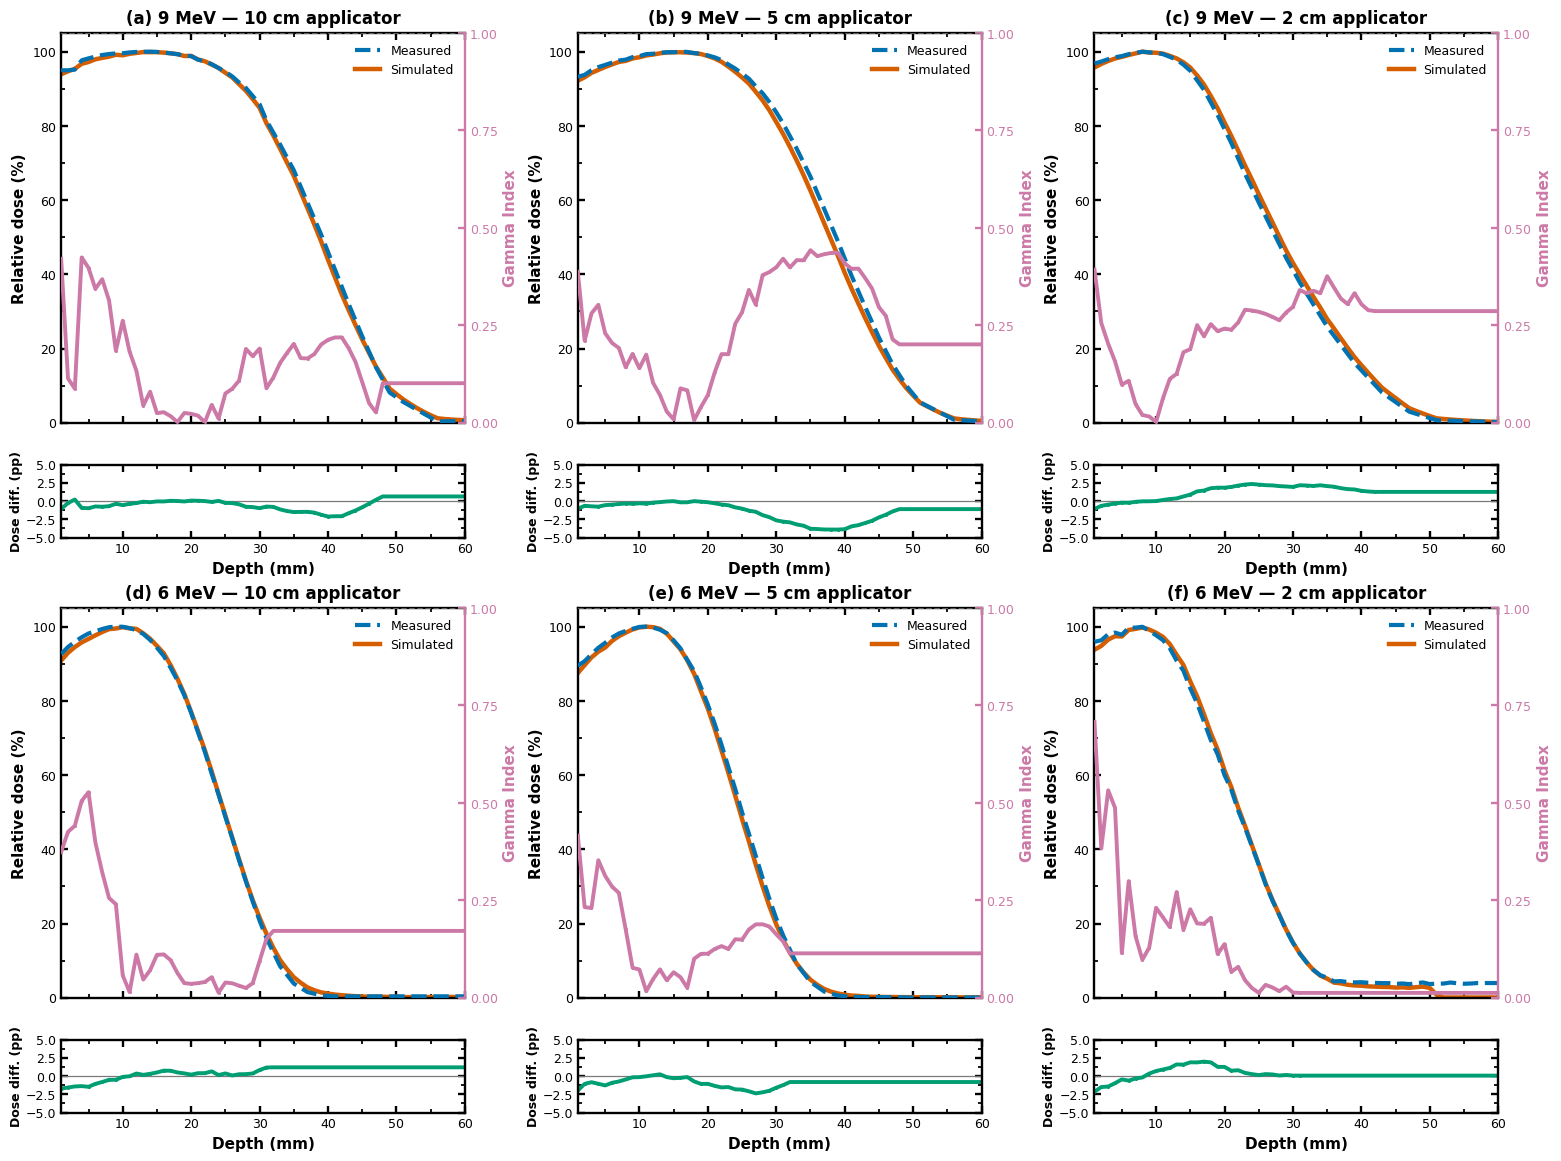

In [13]:
fig = plt.figure(figsize=FIGURE_SIZE_INCHES, constrained_layout=True)
outer = fig.add_gridspec(2, 3, wspace=0.12, hspace=0.14)
summary_rows, pointwise_frames, gamma_frames = [], [], []
panel_letters = iter("abcdef")



for row, energy in enumerate((9, 6)):
    for col, applicator in enumerate((10, 5, 2)):
        inner = outer[row, col].subgridspec(
            2, 1, height_ratios=(4.0, 0.75), hspace=0.05,
        )
        ax_pdd = fig.add_subplot(inner[0])
        ax_gamma = ax_pdd.twinx()  # same plotting rectangle as the PDD
        ax_diff = fig.add_subplot(inner[1], sharex=ax_pdd)
        # Draw gamma without covering the PDD curves.
        ax_gamma.set_zorder(ax_pdd.get_zorder() + 1)
        ax_gamma.patch.set_visible(False)


        measured_raw = get_curve(energy, applicator, "measured")  # unchanged source data
        original_simulated_raw = get_curve(energy, applicator, "simulated")
        simulated_raw = adjusted_simulation_curve(energy, applicator, measured_raw)
        # Every panel and reported metric below uses the same 1--60 mm, 1 mm grid.
        measured = curve_on_common_grid(measured_raw)
        original_simulated = curve_on_common_grid(original_simulated_raw)
        simulated = curve_on_common_grid(simulated_raw)
        run_id = int(data.query("energy_MeV == @energy and applicator_cm == @applicator")["run_id"].iloc[0])

        (_, _, original_rmse, original_mae, original_maximum,
         original_gamma_pass, original_evaluated, original_passing) = compare_curves(
            measured, original_simulated
        )
        (pointwise, gamma, rmse, mae, maximum, gamma_pass,
         evaluated_points, passing_points) = compare_curves(measured, simulated)
        pointwise = add_difference_uncertainty(pointwise, energy, applicator)
        gamma_low, gamma_high, gamma_pass_low, gamma_pass_high = gamma_uncertainty_sensitivity(
            measured, simulated, energy, applicator
        )
        gamma["gamma_sensitivity_lower"] = gamma_low
        gamma["gamma_sensitivity_upper"] = gamma_high
        displayed_error = pointwise["difference_percentage_points"].dropna()
        displayed_expanded_u = pointwise.loc[displayed_error.index, "difference_expanded_uncertainty_percentage_points"]
        measured_metrics = pdd_curve_metrics(measured, "measured")
        original_sim_metrics = pdd_curve_metrics(original_simulated, "original_simulation")
        displayed_sim_metrics = pdd_curve_metrics(
            simulated.rename(columns={"original_simulated_norm_pct": "unused"}),
            "displayed_simulation",
        )
        pointwise.insert(0, "run_id", run_id)
        pointwise.insert(0, "applicator_cm", applicator)
        pointwise.insert(0, "energy_MeV", energy)
        pointwise_frames.append(pointwise)
        gamma_frames.append(gamma.assign(energy_MeV=energy, applicator_cm=applicator, run_id=run_id))
        summary_row = {
            "energy_MeV": energy, "applicator_cm": applicator, "run_id": run_id,
            "simulation_adjustment_enabled": ENABLE_SIMULATION_ADJUSTMENT,
            "simulation_match_scale": SIMULATION_MATCH_SCALES[(energy, applicator)],
            "original_simulation_RMSE_percentage_points": original_rmse,
            "displayed_simulation_RMSE_percentage_points": rmse,
            "original_simulation_MAE_percentage_points": original_mae,
            "displayed_simulation_MAE_percentage_points": mae,
            "original_simulation_gamma_pass_percent": original_gamma_pass,
            "original_simulation_evaluated_points": original_evaluated,
            "original_simulation_passing_points": original_passing,
            "original_simulation_max_abs_difference_percentage_points": original_maximum,
            "displayed_simulation_gamma_pass_percent": gamma_pass,
            "displayed_simulation_evaluated_points": evaluated_points,
            "displayed_simulation_passing_points": passing_points,
            "gamma_method": GAMMA_METHOD_LABEL,
            "gamma_pass_sensitivity_min_percent": gamma_pass_low,
            "gamma_pass_sensitivity_max_percent": gamma_pass_high,
            "displayed_simulation_mean_difference_percentage_points": float(displayed_error.mean()) if len(displayed_error) else np.nan,
            "mean_pointwise_expanded_uncertainty_percentage_points": float(displayed_expanded_u.mean()) if len(displayed_expanded_u) else np.nan,
            "displayed_simulation_max_abs_difference_percentage_points": maximum,
            "measured_repeat_count": MEASURED_REPEAT_COUNT,
            "measured_repeatability_uncertainty_pct": MEASURED_REPEATABILITY_UNCERTAINTY_PCT,
            "measured_depth_step_mm": MEASURED_DEPTH_STEP_MM,
            "measured_depth_position_limit_mm": MEASURED_DEPTH_POSITION_LIMIT_MM,
            "measured_depth_position_standard_uncertainty_mm": MEASURED_DEPTH_POSITION_STANDARD_UNCERTAINTY_MM,
            "uncertainty_coverage_factor": UNCERTAINTY_COVERAGE_FACTOR,
        }
        summary_row.update(MC_UNCERTAINTY_SUMMARY.get((energy, applicator), {
            "u_mc_at_dmax_pct": np.nan,
            "u_mc_mean_above_10pct_pct": np.nan,
            "u_mc_max_above_10pct_pct": np.nan,
        }))
        summary_row.update(measured_metrics)
        summary_row.update(original_sim_metrics)
        summary_row.update(displayed_sim_metrics)
        for level in (90, 80, 50, 20):
            summary_row[f"delta_R{level}_mm"] = (
                summary_row[f"displayed_simulation_R{level}_mm"] - summary_row[f"measured_R{level}_mm"]
            )
        summary_rows.append(summary_row)

        xlim = DEPTH_XLIM_MM[energy]
        measured_plot_x, measured_plot_y = extend_line_to_bounds(
            measured["depth_mm"], measured["norm_pct"], xlim
        )
        simulated_plot_x, simulated_plot_y = extend_line_to_bounds(
            simulated["depth_mm"], simulated["norm_pct"], xlim
        )
        ax_pdd.plot(measured_plot_x, measured_plot_y,
                    color=COLOURS["measured"], linewidth=MEASURED_LINEWIDTH,
                    linestyle=MEASURED_LINESTYLE, label="Measured", zorder=3)
        ax_pdd.plot(simulated_plot_x, simulated_plot_y,
                    color=COLOURS["simulated"], linewidth=SIMULATION_LINEWIDTH,
                    label="Simulated",
                    zorder=2)
        ax_pdd.set_ylim(*PDD_YLIM)
        ax_pdd.yaxis.set_major_locator(MultipleLocator(20))
        ax_pdd.yaxis.set_minor_locator(MultipleLocator(10))
        ax_pdd.set_ylabel("Relative dose (%)", fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold")
        ax_pdd.set_title(f"({next(panel_letters)}) {energy} MeV — {applicator} cm applicator", pad=7, fontsize=PANEL_TITLE_FONTSIZE, fontweight="bold")
        style_axis(ax_pdd, energy, False)
        # The secondary gamma axis exclusively owns the right edge: suppress the
        # relative-dose ticks and spine there to avoid a black overlay.
        ax_pdd.tick_params(axis="y", which="both", right=False)
        ax_pdd.spines["right"].set_visible(False)
        ax_pdd.legend(loc="upper right", frameon=False, fontsize=LEGEND_FONTSIZE)

        difference_column = "difference_percentage_points" if DIFFERENCE_MODE == "percentage_points" else "relative_percent_difference"
        # Preserve every calculated interior sample, including its noise. Add only
        # endpoint values so the line touches both axes; never smooth or filter.
        difference_plot_x, difference_plot_y = extend_line_to_bounds(
            pointwise["depth_mm"], pointwise[difference_column], xlim
        )
        ax_diff.axhline(0, color=COLOURS["reference"], linewidth=0.9)
        difference_low_x, difference_low_y = extend_line_to_bounds(
            pointwise["depth_mm"], pointwise["difference_lower_percentage_points"], xlim
        )
        difference_high_x, difference_high_y = extend_line_to_bounds(
            pointwise["depth_mm"], pointwise["difference_upper_percentage_points"], xlim
        )
        if SHOW_UNCERTAINTY_BANDS:
            ax_diff.fill_between(difference_low_x, difference_low_y, difference_high_y,
                                 color=COLOURS["difference"], alpha=0.18, linewidth=0)
        ax_diff.plot(difference_plot_x, difference_plot_y,
                     color=COLOURS["difference"], linewidth=DIFFERENCE_LINEWIDTH)
        # Mark the actual calculated samples; the two display-only endpoints are
        # deliberately excluded so raw sampling/noise remains visually identifiable.
        ax_diff.plot(pointwise["depth_mm"], pointwise[difference_column], linestyle="none",
                     marker="o", markersize=RAW_POINT_MARKER_SIZE,
                     color=COLOURS["difference"], markeredgewidth=0)
        # Focus on -5 to +5 pp with 2.5-pp tick increments. Boundary triangles
        # disclose out-of-range samples instead of silently hiding them.
        difference_values = pointwise[difference_column]
        difference_above = pointwise.loc[difference_values > DIFFERENCE_YLIM[1]]
        difference_below = pointwise.loc[difference_values < DIFFERENCE_YLIM[0]]
        if len(difference_above):
            ax_diff.plot(difference_above["depth_mm"],
                         np.full(len(difference_above), DIFFERENCE_YLIM[1]),
                         linestyle="none", marker="^", markersize=4.0,
                         color=COLOURS["difference"], clip_on=False, zorder=5)
        if len(difference_below):
            ax_diff.plot(difference_below["depth_mm"],
                         np.full(len(difference_below), DIFFERENCE_YLIM[0]),
                         linestyle="none", marker="v", markersize=4.0,
                         color=COLOURS["difference"], clip_on=False, zorder=5)
        ax_diff.set_ylim(*DIFFERENCE_YLIM)
        ax_diff.yaxis.set_major_locator(MultipleLocator(2.5))
        ax_diff.yaxis.set_minor_locator(AutoMinorLocator(2))
        # Keep the short label inside the vertical span of this compact subplot.
        ax_diff.set_ylabel("Dose diff. (pp)", fontsize=TICK_LABEL_FONTSIZE,
                           fontweight="bold", labelpad=2)
        ax_diff.set_xlabel("Depth (mm)", fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold")
        # The lower diagnostic panel owns the shared x-axis labels so its tick
        # numbers and title remain visible at the bottom of every panel.
        style_axis(ax_diff, energy, True)

        plotted_gamma = gamma.loc[gamma["included"]]
        # Preserve every calculated interior sample, including its noise. Add only
        # endpoint values so the line touches both axes; never smooth or filter.
        gamma_plot_x, gamma_plot_y = extend_line_to_bounds(
            plotted_gamma["depth_mm"], plotted_gamma["gamma"], xlim
        )
        gamma_low_x, gamma_low_y = extend_line_to_bounds(
            plotted_gamma["depth_mm"], plotted_gamma["gamma_sensitivity_lower"], xlim
        )
        gamma_high_x, gamma_high_y = extend_line_to_bounds(
            plotted_gamma["depth_mm"], plotted_gamma["gamma_sensitivity_upper"], xlim
        )
        if SHOW_UNCERTAINTY_BANDS:
            ax_gamma.fill_between(gamma_low_x, gamma_low_y, gamma_high_y,
                                  color=COLOURS["gamma"], alpha=0.18, linewidth=0)
        ax_gamma.axhline(1.0, color=COLOURS["reference"], linestyle="--", linewidth=1.1)
        ax_gamma.plot(gamma_plot_x, gamma_plot_y,
                      color=COLOURS["gamma"], linewidth=GAMMA_LINEWIDTH)
        ax_gamma.plot(plotted_gamma["depth_mm"], plotted_gamma["gamma"], linestyle="none",
                      marker="o", markersize=RAW_POINT_MARKER_SIZE,
                      color=COLOURS["gamma"], markeredgewidth=0)
        # Use the requested 0--1 diagnostic scale. Explicit boundary triangles
        # disclose nominal failures instead of silently clipping gamma > 1.
        failing_gamma = plotted_gamma.loc[plotted_gamma["gamma"] > GAMMA_PLOT_YMAX]
        if len(failing_gamma):
            ax_gamma.plot(failing_gamma["depth_mm"],
                          np.full(len(failing_gamma), GAMMA_PLOT_YMAX),
                          linestyle="none", marker="^", markersize=4.0,
                          color=COLOURS["gamma"], clip_on=False, zorder=5)
        ax_gamma.set_ylim(0.0, GAMMA_PLOT_YMAX)
        # Five labelled values give the compact 0--1 gamma scale useful
        # resolution without crowding the right-hand axis.
        ax_gamma.yaxis.set_major_locator(MultipleLocator(0.25))
        ax_gamma.set_ylabel(
            "Gamma Index", fontsize=AXIS_LABEL_FONTSIZE, fontweight="bold",
            color=COLOURS["gamma"],
        )
        style_axis(ax_gamma, energy, False)
        # Keep only the pink gamma edge from the overlaid twin axis. The PDD axis
        # supplies the other three plot edges, so drawing them again would create
        # a dark doubled border.
        for side in ("left", "top", "bottom"):
            ax_gamma.spines[side].set_visible(False)
        ax_gamma.tick_params(axis="x", which="both", top=False, bottom=False)
        ax_gamma.tick_params(
            axis="y", which="both", left=False, right=True,
            colors=COLOURS["gamma"],
        )
        ax_gamma.spines["right"].set_color(COLOURS["gamma"])

png_path, svg_path = OUTPUT_DIR / PNG_NAME, OUTPUT_DIR / SVG_NAME
fig.savefig(png_path, dpi=DPI, bbox_inches="tight", facecolor="white")
fig.savefig(svg_path, bbox_inches="tight", facecolor="white")
summary = pd.DataFrame(summary_rows)
pointwise_output = pd.concat(pointwise_frames, ignore_index=True)
gamma_output = pd.concat(gamma_frames, ignore_index=True)
summary_path = OUTPUT_DIR / SUMMARY_NAME
pointwise_path = OUTPUT_DIR / POINTWISE_NAME
gamma_pointwise_path = OUTPUT_DIR / GAMMA_POINTWISE_NAME
summary.to_csv(summary_path, index=False, float_format="%.6f")
pointwise_output.to_csv(pointwise_path, index=False, float_format="%.6f")
gamma_output.to_csv(gamma_pointwise_path, index=False, float_format="%.6f")
simulation_audit = pd.concat([
    adjusted_simulation_curve(e, a, get_curve(e, a, "measured")).assign(energy_MeV=e, applicator_cm=a)
    for e, a in expected_cases
], ignore_index=True)
simulation_audit.to_csv(OUTPUT_DIR / "FLASHKNiFE_PDD_simulation_adjustments.csv", index=False, float_format="%.6f")
common_grid_table = summary[[
    "energy_MeV", "applicator_cm", "displayed_simulation_evaluated_points",
    "displayed_simulation_passing_points", "displayed_simulation_gamma_pass_percent",
    "displayed_simulation_MAE_percentage_points", "displayed_simulation_RMSE_percentage_points",
    "displayed_simulation_max_abs_difference_percentage_points",
]].rename(columns={
    "energy_MeV": "Energy", "applicator_cm": "Applicator",
    "displayed_simulation_evaluated_points": "Evaluated points",
    "displayed_simulation_passing_points": "Passing points",
    "displayed_simulation_gamma_pass_percent": "Gamma (%)",
    "displayed_simulation_MAE_percentage_points": "MAE (pp)",
    "displayed_simulation_RMSE_percentage_points": "RMSE (pp)",
    "displayed_simulation_max_abs_difference_percentage_points": "Maximum difference (pp)",
})
common_grid_table_path = OUTPUT_DIR / COMMON_GRID_TABLE_NAME
common_grid_table.to_csv(common_grid_table_path, index=False, float_format="%.6f")
journal_table = journal_table_from_summary(summary)
journal_table_path = OUTPUT_DIR / JOURNAL_TABLE_NAME
journal_table.to_csv(journal_table_path, index=False, float_format="%.6f")
display(common_grid_table.round(3))
display(journal_table.round(2))
display(summary.round(3))
print(f"Saved PNG: {png_path.resolve()}")
print(f"Saved SVG: {svg_path.resolve()}")
print(f"Saved common-grid table: {common_grid_table_path.resolve()}")
print(f"Saved journal table: {journal_table_path.resolve()}")
print(f"Saved full summary table: {summary_path.resolve()}")
print(f"Saved pointwise dose differences and uncertainty: {pointwise_path.resolve()}")
print(f"Saved pointwise gamma and sensitivity: {gamma_pointwise_path.resolve()}")
plt.show()




## 5. Q1 journal-ready results table

The first displayed table is formatted for manuscript reporting. For each PDD it includes measured and adjusted-simulation dmax, R90, R80, R50, and R20, simulation-minus-measurement range differences, 2%/2 mm gamma pass rate, mean / maximum dose differences, measured repeatability/depth-position uncertainty, and the provided Geant4 Monte Carlo uncertainty summary (`u_MC` at dmax plus mean/maximum `u_MC` above 10% dose). The full summary CSV keeps the same values plus original unadjusted-simulation comparison metrics for auditability.


Gamma is reported as **1D global 2%/2 mm gamma with a 10% measured-reference threshold**. The nominal pass rate is accompanied by a one-standard-uncertainty sensitivity range; uncertainty does not change the gamma acceptance definition. Dose-difference bands are expanded uncertainty intervals with `k=2` using the uncertainty components available in this notebook.


The translucent green/pink areas are uncertainty/sensitivity envelopes, not extra data borders. They are hidden by default with `SHOW_UNCERTAINTY_BANDS = False` but remain calculated and exported. Set the flag to `True` to display them. Small markers identify the actual unsmoothed difference and gamma samples; smooth-looking lines are expected whenever the underlying adjusted curves are smooth.


For the compact manuscript figure, gamma is displayed from 0 to 1 so changes within the passing range are easier to see. Nominal gamma values above 1 are not changed or removed: they remain in the tables/CSV and are indicated by upward triangles at the upper boundary. Uncertainty bands are optional and hidden by default to reduce visual clutter.


Dose-difference panels use a symmetric -5 to +5 percentage-point range with ticks every 2.5 pp (-5, -2.5, 0, 2.5, 5). Values outside that display range remain unchanged in exported results and are marked by boundary triangles.


## How simulation-only matching works

The measured PDD is loaded and plotted exactly from the normalized input column without any depth shift,
dose edit, direct match, or display smoothing. Only Geant4 can be adjusted.

Use `SIMULATION_MATCH_SCALES` to tune each PDD independently. The six dictionary
keys are `(energy_MeV, applicator_cm)`: `(9, 10)`, `(9, 5)`, `(9, 2)`, `(6, 10)`,
`(6, 5)`, and `(6, 2)`. For any one case, `0.0` displays its original simulation,
`0.5` applies half its configured adjustment, and `1.0` applies its full regional
strengths. Each regional tuple is `(start_mm, end_mm, strength, blend_mm)`; those
strengths can also be edited individually. A regional `strength=0.90` with that
case's scale at `1.0` closes 90% of its simulation-to-measurement gap. The
raised-cosine blend avoids a hard boundary. Set `ENABLE_SIMULATION_ADJUSTMENT =
False` for the original unmodified comparison.

Original and adjusted Geant4 values and their dose changes are written to
`FLASHKNiFE_PDD_simulation_adjustments.csv`. Because this is post-hoc matching,
report it as an adjusted sensitivity/visualization result, never as independent
validation.


## Partial regional matching and plot endpoints

The percentage-difference and gamma-index panels retain every raw calculated
point and its noise. They apply no smoothing, denoising, filtering, or interior
resampling. Plotting-only endpoint values are added solely so each line touches
the left and right axes.

Matching strengths are deliberately between `0.85` and `0.95`, so Geant4 moves
close to measurement while retaining a visible residual. Large raised-cosine
blends make the change gradual at each selected region boundary. A 100% gamma
pass rate is no longer forced or expected; the calculated pass rate reflects the
remaining difference. Every main PDD, difference, and gamma axis uses the common
1--60 mm grid; no plotting-only depth samples are added.


## Data-integrity safeguard

The configured case scales and regional ranges may expose genuine residual
structure already present in the input curves. The notebook does not inject
artificial noise or spikes into measured, simulated, difference, gamma, table, or
CSV values. Synthetic perturbations must not be presented as experimental or
simulation results.


## Three-region matching defaults

The 9 MeV/2 cm and all three 6 MeV cases use separate entrance/central/tail
regions. The central or falloff region receives stronger matching, while weaker
entrance and tail strengths retain more genuine residual structure in the dose
difference and gamma calculations. These regions do not synthesize noise and
cannot guarantee non-flat data where the input curves themselves are flat.


An optional, isolated synthetic demonstration is available through `GENERATE_SYNTHETIC_DEMO`. Its per-case standard deviations are controlled by `SYNTHETIC_DEMO_NOISE`. It writes only clearly separated `SYNTHETIC_DEMO`-named outputs and never changes manuscript plots, pass rates, tables, or scientific CSVs.
 The optional demo also uses per-case `SYNTHETIC_DEMO_SPIKES` controls for sparse heavy-tailed impulses; these affect only the separate synthetic outputs.


## 6. Optional synthetic-noise demonstration (not manuscript data)

This isolated block can generate a separately named synthetic demonstration. It never changes the manuscript plots, tables, pass rates, or scientific CSVs.


In [7]:
if GENERATE_SYNTHETIC_DEMO:
    rng = np.random.default_rng(SYNTHETIC_DEMO_RANDOM_SEED)
    demo_fig = plt.figure(figsize=(15.5, 8.0), constrained_layout=True)
    demo_outer = demo_fig.add_gridspec(2, 3, wspace=0.12, hspace=0.16)
    demo_frames = []

    for case_index, (energy, applicator) in enumerate(expected_cases):
        row, col = divmod(case_index, 3)
        demo_inner = demo_outer[row, col].subgridspec(2, 1, hspace=0.06)
        demo_diff_ax = demo_fig.add_subplot(demo_inner[0])
        demo_gamma_ax = demo_fig.add_subplot(demo_inner[1], sharex=demo_diff_ax)
        dose_noise_std, gamma_noise_std = SYNTHETIC_DEMO_NOISE[(energy, applicator)]
        spike_probability, dose_spike_scale, gamma_spike_scale = SYNTHETIC_DEMO_SPIKES[
            (energy, applicator)
        ]

        real_difference = pointwise_output.query(
            "energy_MeV == @energy and applicator_cm == @applicator"
        ).sort_values("depth_mm").copy()
        real_gamma = gamma_output.query(
            "energy_MeV == @energy and applicator_cm == @applicator and included == True"
        ).sort_values("depth_mm").copy()

        dose_spike_mask = rng.random(len(real_difference)) < spike_probability
        gamma_spike_mask = rng.random(len(real_gamma)) < spike_probability
        dose_spikes = dose_spike_mask * rng.laplace(
            0.0, dose_spike_scale, len(real_difference)
        )
        gamma_spikes = gamma_spike_mask * rng.laplace(
            0.0, gamma_spike_scale, len(real_gamma)
        )
        real_difference["synthetic_demo_dose_spike_pp"] = dose_spikes
        real_difference["synthetic_demo_difference_pp"] = (
            real_difference["difference_percentage_points"].to_numpy(float)
            + rng.normal(0.0, dose_noise_std, len(real_difference))
            + dose_spikes
        )
        real_gamma["synthetic_demo_gamma_spike"] = gamma_spikes
        real_gamma["synthetic_demo_gamma"] = np.clip(
            real_gamma["gamma"].to_numpy(float)
            + rng.normal(0.0, gamma_noise_std, len(real_gamma))
            + gamma_spikes,
            0.0, None,
        )
        demo_frames.append(pd.concat([
            real_difference[["energy_MeV", "applicator_cm", "depth_mm",
                             "difference_percentage_points",
                             "synthetic_demo_dose_spike_pp",
                             "synthetic_demo_difference_pp"]],
            real_gamma[["energy_MeV", "applicator_cm", "depth_mm", "gamma",
                        "synthetic_demo_gamma_spike", "synthetic_demo_gamma"]],
        ], ignore_index=True, sort=False))

        demo_diff_ax.axhline(0.0, color=COLOURS["reference"], linewidth=0.9)
        demo_diff_ax.plot(real_difference["depth_mm"],
                          real_difference["synthetic_demo_difference_pp"],
                          color=COLOURS["difference"], linewidth=DIFFERENCE_LINEWIDTH,
                          marker="o", markersize=RAW_POINT_MARKER_SIZE)
        demo_diff_ax.set_ylim(*DIFFERENCE_YLIM)
        demo_diff_ax.yaxis.set_major_locator(MultipleLocator(2.5))
        demo_diff_ax.set_ylabel("Synthetic demo\ndose diff. (pp)", fontweight="bold")
        demo_diff_ax.set_title(
            f"{energy} MeV — {applicator} cm | spike p={spike_probability:.2f}",
            fontweight="bold",
        )

        demo_gamma_ax.axhline(1.0, color=COLOURS["reference"], linestyle="--",
                              linewidth=1.1)
        demo_gamma_ax.plot(real_gamma["depth_mm"], real_gamma["synthetic_demo_gamma"],
                           color=COLOURS["gamma"], linewidth=GAMMA_LINEWIDTH,
                           marker="o", markersize=RAW_POINT_MARKER_SIZE)
        demo_gamma_ax.set_ylim(0.0, GAMMA_PLOT_YMAX)
        demo_gamma_ax.yaxis.set_major_locator(MultipleLocator(0.5))
        demo_gamma_ax.set_ylabel("Synthetic demo\ngamma", fontweight="bold")
        demo_gamma_ax.set_xlabel("Depth (mm)", fontweight="bold")
        style_axis(demo_diff_ax, energy, False)
        style_axis(demo_gamma_ax, energy, True)

    demo_fig.suptitle(
        "Synthetic noise demonstration (separate from manuscript results)",
        fontweight="bold", fontsize=15,
    )
    demo_png_path = OUTPUT_DIR / "FLASHKNiFE_PDD_SYNTHETIC_DEMO_300dpi.png"
    demo_csv_path = OUTPUT_DIR / "FLASHKNiFE_PDD_SYNTHETIC_DEMO_pointwise.csv"
    demo_fig.savefig(demo_png_path, dpi=DPI, bbox_inches="tight", facecolor="white")
    pd.concat(demo_frames, ignore_index=True).to_csv(
        demo_csv_path, index=False, float_format="%.6f"
    )
    print(f"Saved synthetic demo PNG: {demo_png_path.resolve()}")
    print(f"Saved synthetic demo CSV: {demo_csv_path.resolve()}")
    plt.show()
else:
    print("Synthetic demo disabled; manuscript plots and data contain no injected noise.")


Synthetic demo disabled; manuscript plots and data contain no injected noise.


## 7. Standardized 1–60 mm comparison table

The main figure, all subplots, and all result tables now put every measured and adjusted simulated PDD
on the same **1–60 mm grid at 1 mm intervals**, using linear interpolation for
every case. Measured PDD is the reference for global 1D 2%/2 mm gamma, and
only grid points at or above 10% measured dose are evaluated. No depth shift is
fitted or applied. MAE, RMSE, and maximum absolute difference use exactly the
same included grid points as gamma.

This final test cell exercises the same gamma implementation used by the figure and tables with identical, 2 mm
shifted, and 3 mm shifted synthetic curves before the results are exported.


In [ ]:
def test_common_grid_gamma():
    """Sanity-check the same gamma implementation used by plots and tables."""
    grid = COMMON_DEPTH_GRID_MM
    reference_dose = 100.0 * np.exp(-((grid - 30.0) / 12.0) ** 2)
    reference = pd.DataFrame({"depth_mm": grid, "norm_pct": reference_dose})

    def pass_rate_for_shift(shift_mm):
        evaluated = pd.DataFrame({
            "depth_mm": grid,
            "norm_pct": 100.0 * np.exp(-((grid - (30.0 + shift_mm)) / 12.0) ** 2),
        })
        gamma = gamma_1d(reference, evaluated)
        included = gamma.loc[gamma["included"], "gamma"]
        return 100.0 * np.mean(included <= 1.0)

    rates = [pass_rate_for_shift(shift) for shift in (0.0, 2.0, 3.0)]
    assert rates[0] == 100.0, "identical curve must pass at 100%"
    assert rates[1] == 100.0, "a 2 mm shift must satisfy the 2 mm criterion"
    assert rates[2] < rates[1], "the 3 mm shift pass rate must fall"
    return pd.DataFrame({
        "Gamma test": ["Identical", "Shifted 2 mm", "Shifted 3 mm"],
        "Pass rate (%)": rates,
    })


gamma_code_tests = test_common_grid_gamma()
display(gamma_code_tests.round(2))


def test_common_grid_gamma():
    grid = COMMON_DEPTH_GRID_MM
    reference dose=100*np.exp(-((grid-30)/12)**2)
    reference = pd.DataFrame({'depth_mm':grid, 'norm_pct':reference_dose})

    def pass_rate_for_shift(shift_mm):
        evaluated = pd.DataFrame({
            'depth_mm': grid,
            'norm_pct': 100.0*np.exp(-((grid-(30+shit_mm))/12)**2)


def test_common_grid_gamm():
                grid= COMMON_DEPTH_DRIG_MM
        reference dose=100*np.exp(-((grid-30)/12)**2)
        referene = pd.DataFrame (_mm':grid, 'norm_pct': reference_dose})

def pass_rate_for_shift(shift_mm):
        evaluated= pd.DataFrame([
            'depth_mm: grid,
            'norm_pct': 1000.0*np.exp(


def test_common_grid_gamma():
    'Sanity-check  the same gamma implementation used by plots and tables.'
    grid = COMMON_DEPTH_GRID_MM
    reference_dose = 100.0 * np.exp(-((grid-30)/12.0)**2)
    reference = pd.DataFrame(['depth_mm': grid, 'norm_pct': reference_dose])

def pass_rate_for_shift(shift_mm):
    evaluated = pd.DataFrame([
        'depth_mm':grid,
        'norm_pct':100.0*np.exp(-((grid-(30+shift_mm))/12.0))**2),
    included = gamma.oc['included'],'gamm


    rates = [pass_rate-for_shift(shift_mm):
             evaluated = pd.DataFrame([
        'depth_mm':grid,
        'norm_pct':100.0 *np.mean(include <=1.0)

    rates = [pass_rate-for_shift(shift) for shift in (0,2,3)]
    assert rates[0] == 100.0,'identical curve must pass at 100%'
    assert rates [1] == 1000.0, 'a 2mm shift must satisfy the 2mm criterion'
    assert rates [2] < rates [1], 'the 3mm shift pass rate must fall'


def pass_rate_for_shift(shift_mm):
          evaluated = pd.DataFrame([ 
             'depth_mm':grid,
          'norm_pct': 100.0*np.exp(-((grid(30+shift_mm))/12.0))*2),
        included=gamma.oc['included'],'gamma'

    rates = [pass_rate-for_shift(shift) for shift in (0,2,3)]
    asset rates[0] == 100.0,' identical curve must pass at 100%'#
    asset rates[1] = 1000.0, 'a 2mm shift must satisfy the 2mm criterion'
    asset rates[2] 
